In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [2]:
housing_full = pd.read_csv(Path("datasets/housing/housing.csv"))

In [3]:
housing_full.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
housing_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


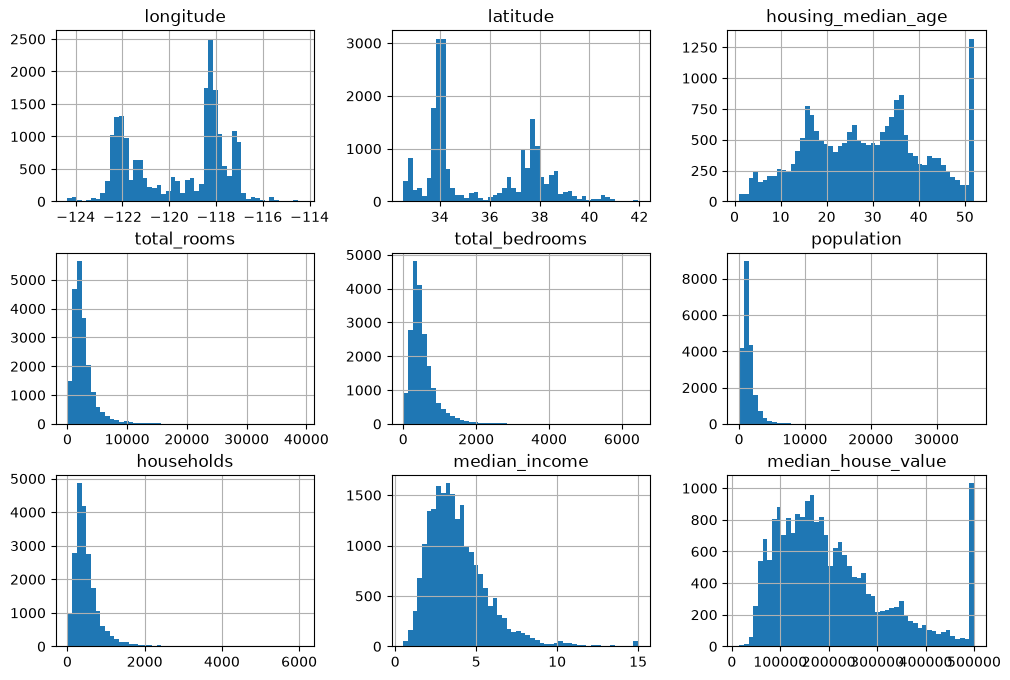

In [5]:
housing_full.hist(bins=50, figsize=(12, 8))
plt.show()

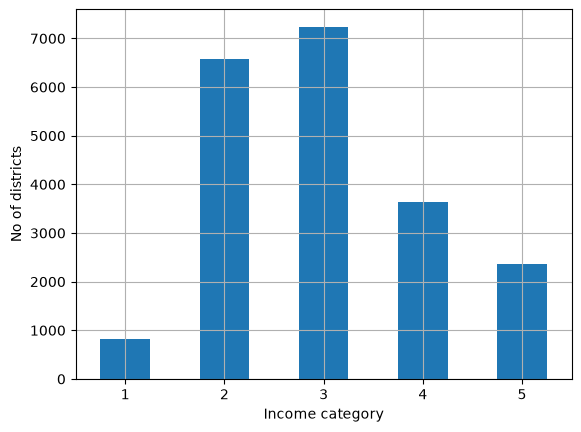

164.4
472.40000000000003


In [6]:
housing_full["income_cat"] = pd.cut(housing_full["median_income"],
                                    bins=[0,1.5,3.0,4.5,6, np.inf],
                                    labels=[1,2,3,4,5])

cat_counts = housing_full['income_cat'].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid = True)
plt.xlabel("Income category")
plt.ylabel("No of districts")
plt.show()
print(cat_counts[1]*0.2)
print(cat_counts[5]*0.2)

In [7]:
from sklearn.model_selection import train_test_split
strat_train_set, strat_test_set = train_test_split(housing_full, stratify=housing_full["income_cat"], test_size=0.2, random_state=42)
print(len(strat_train_set), len(strat_test_set))

16512 4128


In [8]:
strat_test_set["income_cat"].value_counts()

income_cat
3    1447
2    1316
4     728
5     472
1     165
Name: count, dtype: int64

In [9]:
# As we don't need it cause we made seperations already.
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

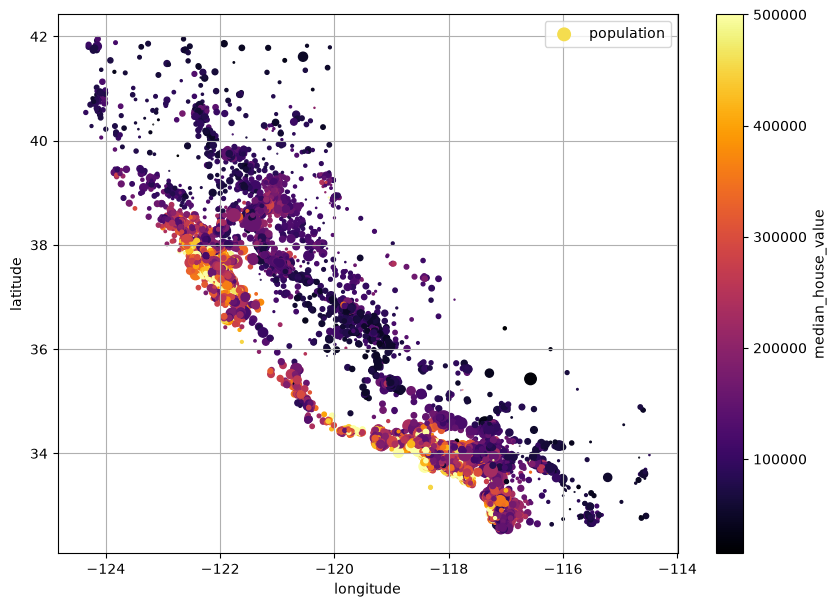

In [10]:
housing = strat_train_set.copy()
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
            s=housing["population"] / 100, label="population",
            c="median_house_value", cmap="inferno", colorbar=True,
            legend=True, sharex=False, figsize=(10,7))
plt.show()

In [11]:
# Finding correlation values/score of each attribute with median_house_value.
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

In [12]:
#Now cleaning process starts to prepare data for ml aogorithms.

housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

#Seperated the labels and instances.


Data cleaning data usually means making data reliable and consumable by ml algorithms.
1. Handling missing values.
2. Removing Duplicates.
3. Fix Incorrect data.
4. Handle outliers.
5. Standardize formats like fonts, styles, upper/lowercase, making similar to avoid confusion.
6. Feature Engineering accumlating data two or more attributtes to make more reliable and effective attribute/s. Reduces data complexity and unwanted features.
7. Convert Categorical Data. ml needs numaerical data, so attributes are encoded into numbers or can be categotised.

In [13]:
# Custom log transformer for scaling
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp, feature_names_out="one-to-one")

In [14]:
# Custom transformer class for finding clusters and similarity score with each cluster.
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_= KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self
    
    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
    
    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [15]:
# Transformation pipelines.
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import  SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import root_mean_squared_error

num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
category_pipeline = make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore"))

In [16]:
# Now for ratios

def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ['ratio']

ratio_pipeline = make_pipeline(SimpleImputer(strategy="median"), FunctionTransformer(column_ratio, feature_names_out=ratio_name), StandardScaler())

In [17]:
#For log 
log_pipeline = make_pipeline(SimpleImputer(strategy="median"), log_transformer)

#Kmeans clusers and rbf similarity.
cluster_simil = ClusterSimilarity(n_clusters=45, gamma=1.0, random_state=42) # Best hyperparameter found after tuning.

In [18]:
#Now we will automate all these under single tranformer:
from sklearn.compose import ColumnTransformer, make_column_selector

preprocessing = ColumnTransformer([
    ("bedrooms", ratio_pipeline, ['total_bedrooms', 'total_rooms']),
    ("rooms_per_house", ratio_pipeline, ['total_rooms', 'households']),
    ("people_per_house", ratio_pipeline, ['population', 'households']),
    ("log", log_pipeline, ['total_bedrooms', 'total_rooms', 'population', 'households', 'median_income']),
    ("geo", cluster_simil, ['latitude', 'longitude']),
    ("cat", category_pipeline, make_column_selector(dtype_include=object))
], remainder=num_pipeline)

In [19]:
# We will be using RandomForestRegressor.
from sklearn.ensemble import RandomForestRegressor

Forest_reg = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42, max_features=9))
])
Forest_reg.fit(housing, housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('random_forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will 

In [20]:
#Evaluate on trraining set
trained_housing_predictions = Forest_reg.predict(housing)
trained_housing_predictions_rmse = root_mean_squared_error(housing_labels, trained_housing_predictions)
trained_housing_predictions_rmse

15226.887336470707

In [21]:
#Cross_Validation
from sklearn.model_selection import cross_val_score

cv_rmse_score = - cross_val_score(Forest_reg, housing, housing_labels, cv=5, scoring="neg_root_mean_squared_error")
pd.Series(cv_rmse_score).describe()

count        5.000000
mean     41369.616827
std        886.535997
min      39871.627892
25%      41338.162925
50%      41608.327678
75%      41948.474550
max      42081.491089
dtype: float64

In [22]:
# Evaluation on test_set.
test_housing = strat_test_set.drop("median_house_value", axis=1)
test_housing_labels = strat_test_set["median_house_value"].copy()

In [23]:
forest_test_predictions = Forest_reg.predict(test_housing)
forest_test_predictions_rmse = root_mean_squared_error(test_housing_labels, forest_test_predictions)
forest_test_predictions_rmse

41422.06890497527

In [24]:
import joblib

joblib.dump(Forest_reg, "housing_prediction_model.pkl")

['housing_prediction_model.pkl']